# 02 — Walking-Strassennetz, Bevölkerungsraster & Stadtquartiere

**Ziel:** Drei zusätzliche Datenquellen vorbereiten:
1. **OSMnx Walking-Graph** — die Basis für die Isochronen-Berechnung in Notebook 04.
2. **BFS STATPOP 2023** — Bevölkerungsdichte-Hektarraster, später für die Versorgungslücken-Analyse.
3. **Stadt Zürich Open Data** — die 34 statistischen Quartiere.

**Outputs:**
- `data/processed/zh_walk_graph.graphml`
- `data/external/quartiere.geojson`
- `data/external/STATPOP_2023.csv` (manuell herunterzuladen — wir prüfen Existenz)

## 1. Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import geopandas as gpd
import pandas as pd
import requests
import osmnx as ox

from zh15min import config, osm

## 2. Walking-Strassennetz

OSMnx bietet `graph_from_polygon` mit `network_type='walk'`. Der Graph wird simplifiziert (Knoten werden zusammengelegt, wo es nur Durchgangs-Knoten gibt) und als GraphML gespeichert.

In [2]:
boundary = gpd.read_file(config.PROCESSED_DIR / 'zh_boundary.gpkg', layer='boundary')
G = osm.walk_graph(boundary)
print(f'Walking-Graph: {len(G.nodes):,} Knoten, {len(G.edges):,} Kanten')

Walking-Graph: 61,780 Knoten, 164,668 Kanten


In [3]:
graph_path = config.PROCESSED_DIR / 'zh_walk_graph.graphml'
ox.save_graphml(G, graph_path)
print('Graph gespeichert:', graph_path)

Graph gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/processed/zh_walk_graph.graphml


## 3. Statistische Quartiere (Stadt Zürich Open Data)

**Datenquelle:** Stadt Zürich, Open Government Data — `ADM_STATISTISCHE_QUARTIERE_V` (Polygone) + `ADM_STATISTISCHE_QUARTIERE_B_P` (Beschriftungspunkte mit Namen + Kürzel).

**Bezugsweg:**
1. https://www.stadt-zuerich.ch/geodaten/download/Statistische_Quartiere → Service-Schnittstellen → **GeoJSON**
2. Drei GeoJSON-Links kopieren (V, B_P, MAP) und herunterladen
3. Dateien in `data/external/` ablegen
4. Polygone (V) und Namen (B_P) per **räumlichem Join** zusammenführen — `objid` matcht zwischen den Layern *nicht*; die Namen müssen über die Punkt-in-Polygon-Beziehung zugeordnet werden.

Falls die Datei `data/external/quartiere.geojson` bereits existiert (z.B. aus einem vorherigen Lauf), wird sie verwendet. Andernfalls fällt das Notebook auf einen automatischen WFS-Download zurück, der zum Auswertungszeitpunkt allerdings HTTP 500 lieferte — daher der manuelle Weg über die GeoJSON-Schnittstelle.

In [4]:
# Primärquelle: offizieller Stadt-Zürich-GeoJSON-Endpoint
# (manuell heruntergeladen und per räumlichem Join gemerged — siehe Markdown oben)
QUART_URL = (
    'https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere'
    '?service=WFS&version=1.1.0&request=GetFeature'
    '&typename=ms:adm_statistische_quartiere_v&outputFormat=geojson'
)
quart_path = config.EXTERNAL_DIR / 'quartiere.geojson'

if not quart_path.exists():
    print('Versuche WFS-Download…')
    try:
        r = requests.get(QUART_URL, timeout=120)
        r.raise_for_status()
        quart_path.write_bytes(r.content)
        print('OK — gespeichert:', quart_path)
    except Exception as exc:
        print(f'⚠️  WFS-Download fehlgeschlagen ({exc})')
        print('   Manueller Bezug: https://www.stadt-zuerich.ch/geodaten/download/Statistische_Quartiere')
        print('   Bitte ADM_STATISTISCHE_QUARTIERE_V.json + _B_P.json laden und per räumlichem Join in')
        print('   data/external/quartiere.geojson zusammenführen (Helper-Skript: scripts/merge_quartiere.py).')
        raise
else:
    print('Quartiere bereits vorhanden:', quart_path)

quart = gpd.read_file(quart_path).to_crs(config.EPSG_LV95)
print(f'{len(quart)} Quartier-Polygone (offiziell Stadt Zürich)')
quart.head(3)

Quartiere bereits vorhanden: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/external/quartiere.geojson
34 Quartier-Polygone (offiziell Stadt Zürich)


,objid,objectid,name,kuerzel,geometry
0,1,1,Alt-Wiedikon,31,"POLYGON ((2680606.663 1247034.585, 2680606.997..."
1,10,2,Witikon,74,"POLYGON ((2685858.633 1246502.63, 2685859.218 ..."
2,11,3,Langstrasse,42,"POLYGON ((2681313.305 1248613.858, 2681314.803..."


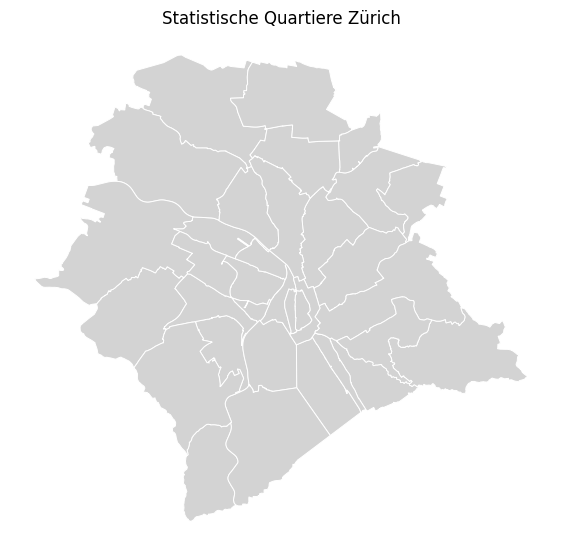

In [5]:
ax = quart.plot(figsize=(7, 7), facecolor='lightgrey', edgecolor='white', linewidth=0.7)
ax.set_title('Statistische Quartiere Zürich', fontsize=12)
ax.set_axis_off();

## 4. STATPOP 2023 (BFS) — Bevölkerung pro Hektar

Die CSV ist nicht per offene API erreichbar (Asset-ID-basierter Download mit Captcha). Bitte einmalig manuell herunterladen:

👉 https://www.bfs.admin.ch/asset/de/32686751

Dann nach `data/external/STATPOP_2023.csv` legen. Die Spalten heissen typischerweise `E_KOORD`, `N_KOORD`, `B23BTOT` (Total Einwohner).

In [6]:
# STATPOP-Datei suchen (flexibel: STATPOP*.csv für beliebige Jahres-Bezeichnung)
from pathlib import Path
candidates = sorted(Path(config.EXTERNAL_DIR).glob('STATPOP*.csv'))
# Aggregate (NOLOC, GMDE) ausschliessen — wir wollen die Hektar-Raster-Datei mit Koordinaten
candidates = [c for c in candidates if 'NOLOC' not in c.name.upper() and 'GMDE' not in c.name.upper()]

if not candidates:
    print('⚠️  STATPOP fehlt — bitte manuell von https://www.bfs.admin.ch/asset/de/32686751 laden.')
    print('    Hektar-Raster-CSV (z.B. STATPOP2024.csv, ~65 MB) nach data/external/ legen.')
    print('    Notebook 06 funktioniert auch ohne, dann fehlt nur die quantitative H2-Validierung.')
else:
    statpop_path = candidates[0]
    print(f'STATPOP-Datei gefunden: {statpop_path.name}')
    statpop = pd.read_csv(statpop_path, sep=';', low_memory=False)
    print(f'STATPOP: {len(statpop):,} Hektarzellen Schweiz')

    # Auf Zürich clippen über Quartier-BBOX in LV95
    minx, miny, maxx, maxy = quart.total_bounds
    pad = 500
    mask = (
        statpop['E_KOORD'].between(minx - pad, maxx + pad)
        & statpop['N_KOORD'].between(miny - pad, maxy + pad)
    )
    pop_zh = statpop.loc[mask].copy()
    pop_zh = gpd.GeoDataFrame(
        pop_zh,
        geometry=gpd.points_from_xy(pop_zh['E_KOORD'], pop_zh['N_KOORD']),
        crs=config.EPSG_LV95,
    )
    pop_zh.to_file(config.PROCESSED_DIR / 'zh_statpop.gpkg', layer='pop_ha', driver='GPKG')
    print(f'Zürich: {len(pop_zh):,} Hektarzellen — gespeichert.')

STATPOP-Datei gefunden: STATPOP2024.csv
STATPOP: 347,736 Hektarzellen Schweiz
Zürich: 8,149 Hektarzellen — gespeichert.


## 5. Zusammenfassung

- ✅ Walking-Graph in `data/processed/zh_walk_graph.graphml`
- ✅ Quartiere in `data/external/quartiere.geojson`
- ⚠️/✅ STATPOP — falls vorhanden in `data/processed/zh_statpop.gpkg`

Weiter mit `03_postgis_import.ipynb`.